Os dados usados são do seguinte banco de dados:

In [ ]:
import kagglehub
path = kagglehub.dataset_download("juniorfazzio/data-of-brazilian-import-and-export-data")
print("Path to dataset files:", path)

Importação de bibliotecas

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import os

Conexão com banco de dados

In [6]:
path = "database.db"
conn = sqlite3.connect(path)

Selecionando os campos que serão usados para gerar o gráfico 

In [11]:
query = """
SELECT CO_ANO, CO_PAIS, CO_NCM, VL_FOB, KG_LIQUIDO
FROM imp_completa
WHERE CO_ANO >= 2015
"""

df = pd.read_sql(query, conn)


Limpando/tratando os dados

In [ ]:
df = df.dropna()

df['CO_ANO'] = df['CO_ANO'].astype(int)
df['VL_FOB'] = df['VL_FOB'].astype(float)
df['KG_LIQUIDO'] = df['KG_LIQUIDO'].astype(float)

Testando e verificando os dados tratados.

In [13]:
print(df.head())
print(df.info())

   CO_ANO  CO_PAIS    CO_NCM   VL_FOB  KG_LIQUIDO
0    2015       87  73181600   1526.0         2.0
1    2015      361  73261900   1458.0       315.0
2    2015       23  49111010  10552.0       301.0
3    2015      399  84819090   1323.0         2.0
4    2015      249  39199000  21968.0        38.0
<class 'pandas.DataFrame'>
RangeIndex: 11575607 entries, 0 to 11575606
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   CO_ANO      int64  
 1   CO_PAIS     int64  
 2   CO_NCM      int64  
 3   VL_FOB      float64
 4   KG_LIQUIDO  float64
dtypes: float64(2), int64(3)
memory usage: 441.6 MB
None


Gerando o primeiro gráfico, tentando achar os 10 paises que mais exportaram produtos para o Brasil

In [19]:
importadores = ( 
    df.groupby('CO_PAIS')['VL_FOB']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

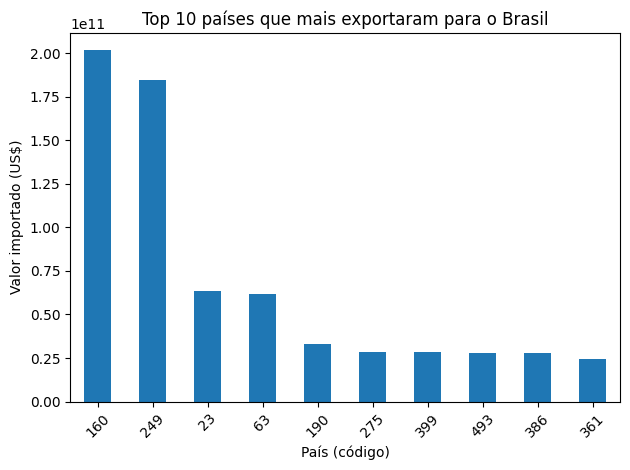

In [ ]:
plt.figure()
importadores.plot(kind='bar')

plt.title('10 países que mais exportaram para o Brasil')
plt.xlabel('País (código)')
plt.ylabel('Valor importado (US$)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico foi gerado com sucesso, mas os paises não apareceram com os nomes corretos, e sim por codigos, então puxei os nomes e correlacionei o código dos paises com seus respectivos nomes

In [21]:
query = """
SELECT 
    i.CO_ANO,
    p.NO_PAIS,
    i.CO_NCM,
    i.VL_FOB,
    i.KG_LIQUIDO
FROM imp_completa i
JOIN co_pais p ON i.CO_PAIS = p.CO_PAIS
WHERE i.CO_ANO >= (SELECT MAX(CO_ANO) - 4 FROM imp_completa)
"""

df = pd.read_sql(query, conn)

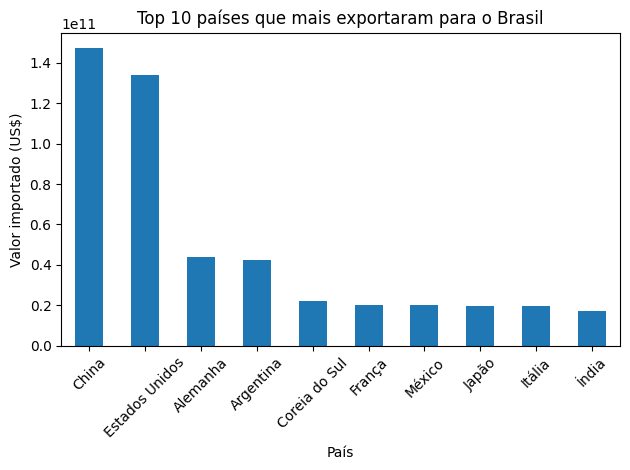

In [ ]:
importadores = (
    df.groupby('NO_PAIS')['VL_FOB']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
importadores.plot(kind='bar')

plt.title('10 países que mais exportaram para o Brasil')
plt.xlabel('País')
plt.ylabel('Valor importado (US$)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico permanece identico, mas vemos que agora com os nomes dos paises.

O Pais que o Brasil mais importou produto nos ultimos 5 anos foi a china. e na lista com os 10 paises que mais exportaram para o Brasil, não há nenhum país do Oriente Médio.

In [43]:
conn = sqlite3.connect(path)

query_energia = """
SELECT CO_ANO, VL_FOB
FROM imp_completa
WHERE CO_NCM = 27160000
AND CO_ANO >= (SELECT MAX(CO_ANO) - 29 FROM imp_completa)
"""

df_energia = pd.read_sql(query_energia, conn)

In [41]:
energia = (
    df_energia.groupby('CO_ANO')['VL_FOB']
    .sum()
    .sort_index()
)

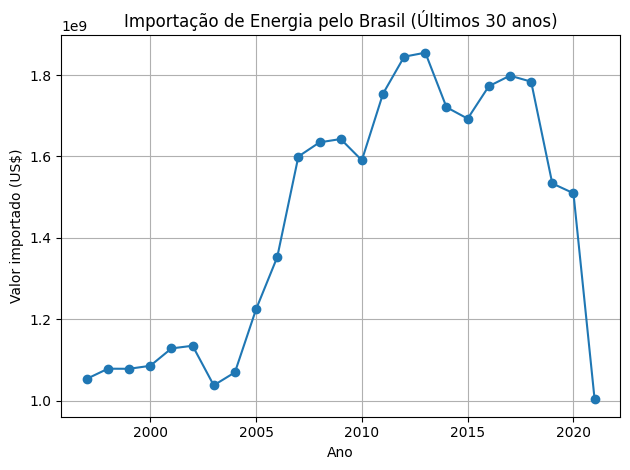

In [42]:
plt.figure()
energia.plot(kind='line', marker='o')

plt.title('Importação de Energia pelo Brasil (Últimos 30 anos)')
plt.xlabel('Ano')
plt.ylabel('Valor importado (US$)')

plt.grid()
plt.tight_layout()
plt.show()